# 04 — Artificial Neural Network / Deep Learning

This notebook evaluates an **Artificial Neural Network (ANN)** for one-month-ahead UK house-price forecasting using PyTorch.

The deep-learning workflow is intentionally aligned with the classical modelling notebook:

- the same leakage-aware modelling table;
- the same chronological training, validation and final-test periods;
- feature scaling fitted only on training data;
- validation-based architecture selection and early stopping;
- no use of the final test period during model selection;
- comparison against the selected classical model and simple forecasting baselines.

The aim is not to assume that deep learning must outperform simpler methods. The aim is to evaluate it fairly and retain the result supported by out-of-time evidence.

## 1. Imports, reproducibility and project paths

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = PROJECT_ROOT / "data" / "processed" / "uk_housing_modelling_base.csv"

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("PyTorch version:", torch.__version__)
print("Project root:", PROJECT_ROOT)
print("Modelling dataset:", MODEL_PATH)

PyTorch version: 2.10.0+cpu
Project root: /mnt/data/ann_project
Modelling dataset: /mnt/data/ann_project/data/processed/uk_housing_modelling_base.csv


## 2. Load the forecasting dataset

In [2]:
df = pd.read_csv(
    MODEL_PATH,
    parse_dates=["forecast_origin", "target_date"],
)

TARGET = "target_house_price_next_month_gbp"

assert len(df) == 160
assert df["forecast_origin"].is_monotonic_increasing
assert not df.isna().any().any()

print(f"Rows: {len(df)}")
print(f"Target period: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
df.head()

Rows: 160
Target period: 2010-01-01 to 2023-04-01


,forecast_origin,target_date,target_house_price_next_month_gbp,house_price_lag_1m_gbp,house_price_lag_3m_gbp,house_price_lag_12m_gbp,house_price_rolling_3m_mean_gbp,house_price_rolling_12m_mean_gbp,sales_volume_lag_1m,average_weekly_earnings_lag_1m_gbp,unemployment_rate_lag_1m_pct,cpi_annual_rate_lag_1m_pct,gdp_monthly_growth_lag_1m_pct,public_sector_net_borrowing_lag_1m_gbp_mn,bank_rate_lag_1m_pct,target_month_sin,target_month_cos
0,2009-12-01,2010-01-01,"167,468.930","168,081.609","166,424.903","157,233.924","167,164.220","161,148.033","87,202.000",440.000,7.700,2.900,0.500,"21,331.000",0.500,0.500,0.866
1,2010-01-01,2010-02-01,"167,887.682","167,468.930","166,986.149","155,417.385","167,512.229","162,000.950","41,084.667",439.000,7.900,3.500,-0.800,"7,697.000",0.500,0.866,0.500
2,2010-02-01,2010-03-01,"167,877.951","167,887.682","168,081.609","154,452.381","167,812.740","163,040.141","47,347.667",446.000,8.000,3.000,1.700,"9,831.000",0.500,1.000,0.000
3,2010-03-01,2010-04-01,"170,027.890","167,877.951","167,468.930","155,852.156","167,744.854","164,158.939","58,046.667",441.000,8.000,3.400,0.800,"13,191.000",0.500,0.866,-0.500
4,2010-04-01,2010-05-01,"170,845.925","170,027.890","167,887.682","158,004.466","168,597.841","165,340.250","59,554.667",441.000,7.900,3.700,-0.200,"9,201.000",0.500,0.500,-0.866


## 3. Feature sets

Notebook 03 showed that the one-month forecasting task is dominated by recent house-price history. This notebook therefore evaluates:

- **Autoregressive ANN:** lagged and rolling house-price features plus month-of-year seasonality;
- **Full ANN:** the same features plus lagged macroeconomic and housing-market indicators.

This comparison tests whether the additional economic variables improve the neural network out of time.

In [3]:
AUTOREGRESSIVE_FEATURES = [
    "house_price_lag_1m_gbp",
    "house_price_lag_3m_gbp",
    "house_price_lag_12m_gbp",
    "house_price_rolling_3m_mean_gbp",
    "house_price_rolling_12m_mean_gbp",
    "target_month_sin",
    "target_month_cos",
]

FULL_FEATURES = [
    c for c in df.columns
    if c not in ["forecast_origin", "target_date", TARGET]
]

print("Autoregressive features:", len(AUTOREGRESSIVE_FEATURES))
print("Full features:", len(FULL_FEATURES))

Autoregressive features: 7
Full features: 14


## 4. Chronological train / validation / final-test split

The split is identical to Notebook 03 so that the ANN and classical models are directly comparable.

- **Training:** 112 observations
- **Validation:** 24 observations
- **Final test:** 24 observations

The final test period remains untouched until the ANN architecture has been selected.

In [4]:
train = df.iloc[:-48].copy()
validation = df.iloc[-48:-24].copy()
test = df.iloc[-24:].copy()

assert len(train) == 112
assert len(validation) == 24
assert len(test) == 24

pd.DataFrame({
    "split": ["Training", "Validation", "Final test"],
    "rows": [len(train), len(validation), len(test)],
    "target_start": [
        train["target_date"].min().date(),
        validation["target_date"].min().date(),
        test["target_date"].min().date(),
    ],
    "target_end": [
        train["target_date"].max().date(),
        validation["target_date"].max().date(),
        test["target_date"].max().date(),
    ],
})

,split,rows,target_start,target_end
0,Training,112,2010-01-01,2019-04-01
1,Validation,24,2019-05-01,2021-04-01
2,Final test,24,2021-05-01,2023-04-01


## 5. Scaling strategy

Neural networks are sensitive to feature scale.

For every architecture trial:

1. the feature scaler is fitted **only on the training period**;
2. the target scaler is fitted **only on the training period**;
3. the same fitted scalers transform the validation period;
4. predictions are converted back to pounds before evaluation.

This prevents future information from entering the preprocessing step.

## 6. ANN architecture

The network is a fully connected feed-forward regressor:

**input → hidden layer(s) with ReLU → one linear output**

The final layer has no activation because house price is a continuous regression target.

In [5]:
class PriceANN(nn.Module):
    def __init__(self, n_features, hidden_layers=(16,), dropout=0.0):
        super().__init__()

        layers = []
        previous = n_features

        for units in hidden_layers:
            layers.append(nn.Linear(previous, units))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            previous = units

        layers.append(nn.Linear(previous, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)

## 7. Evaluation metrics

In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE_pct": mean_absolute_percentage_error(y_true, y_pred) * 100,
        "R2": r2_score(y_true, y_pred),
    }

## 8. Training function with early stopping

Model weights are optimised with Adam and mean-squared-error loss.

Early stopping monitors validation loss. When validation loss no longer improves for the specified patience window, training stops and the best recorded weights are restored.

Because the dataset is small, the candidate architecture search is deliberately compact.

In [7]:
def train_ann_candidate(
    features,
    hidden_layers,
    dropout=0.0,
    learning_rate=0.001,
    weight_decay=0.0,
    max_epochs=2000,
    patience=150,
    seed=SEED,
):
    set_seed(seed)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train = x_scaler.fit_transform(train[features])
    X_valid = x_scaler.transform(validation[features])

    y_train = y_scaler.fit_transform(train[[TARGET]]).ravel()
    y_valid = y_scaler.transform(validation[[TARGET]]).ravel()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    X_valid_t = torch.tensor(X_valid, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    y_valid_t = torch.tensor(y_valid, dtype=torch.float32)

    model = PriceANN(
        n_features=len(features),
        hidden_layers=hidden_layers,
        dropout=dropout,
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    loss_fn = nn.MSELoss()

    train_losses = []
    valid_losses = []

    best_valid_loss = np.inf
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()

        optimizer.zero_grad()
        train_pred = model(X_train_t)
        train_loss = loss_fn(train_pred, y_train_t)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            valid_pred = model(X_valid_t)
            valid_loss = loss_fn(valid_pred, y_valid_t)

        train_losses.append(float(train_loss.item()))
        valid_losses.append(float(valid_loss.item()))

        if valid_loss.item() < best_valid_loss - 1e-7:
            best_valid_loss = valid_loss.item()
            best_state = {
                key: value.detach().clone()
                for key, value in model.state_dict().items()
            }
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    model.load_state_dict(best_state)
    model.eval()

    with torch.no_grad():
        scaled_prediction = model(X_valid_t).numpy().reshape(-1, 1)

    validation_prediction = (
        y_scaler.inverse_transform(scaled_prediction).ravel()
    )

    metrics = regression_metrics(
        validation[TARGET],
        validation_prediction,
    )

    return {
        "model": model,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "prediction": validation_prediction,
        "metrics": metrics,
        "best_epoch": best_epoch + 1,
        "train_losses": train_losses,
        "valid_losses": valid_losses,
    }

## 9. Compact architecture search

Four candidate configurations are evaluated on the same validation window.

The search includes shallow and two-layer networks and compares the autoregressive and full feature sets.

In [8]:
ANN_CONFIGS = {
    "AR ANN — 16": {
        "features": AUTOREGRESSIVE_FEATURES,
        "hidden_layers": (16,),
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 0.0,
    },
    "AR ANN — 32-16": {
        "features": AUTOREGRESSIVE_FEATURES,
        "hidden_layers": (32, 16),
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 0.0,
    },
    "AR ANN — 32-16 + dropout": {
        "features": AUTOREGRESSIVE_FEATURES,
        "hidden_layers": (32, 16),
        "dropout": 0.10,
        "learning_rate": 0.001,
        "weight_decay": 0.0001,
    },
    "Full ANN — 32-16": {
        "features": FULL_FEATURES,
        "hidden_layers": (32, 16),
        "dropout": 0.0,
        "learning_rate": 0.001,
        "weight_decay": 0.0,
    },
}

In [9]:
ann_trials = {}
ann_validation_rows = []

for name, config in ANN_CONFIGS.items():
    result = train_ann_candidate(**config)
    ann_trials[name] = result

    ann_validation_rows.append({
        "model": name,
        "feature_set": (
            "Autoregressive"
            if config["features"] == AUTOREGRESSIVE_FEATURES
            else "Full"
        ),
        "hidden_layers": str(config["hidden_layers"]),
        "dropout": config["dropout"],
        "learning_rate": config["learning_rate"],
        "best_epoch": result["best_epoch"],
        **result["metrics"],
    })

ann_validation = pd.DataFrame(ann_validation_rows)
ann_validation.sort_values("RMSE")

,model,feature_set,hidden_layers,dropout,learning_rate,best_epoch,MAE,RMSE,MAPE_pct,R2
0,AR ANN — 16,Autoregressive,"(16,)",0.000,0.001,233,"2,804.884","3,368.266",1.167,0.807
1,AR ANN — 32-16,Autoregressive,"(32, 16)",0.000,0.001,99,"3,485.082","3,972.773",1.456,0.732
2,AR ANN — 32-16 + dropout,Autoregressive,"(32, 16)",0.100,0.001,93,"3,541.196","4,200.931",1.475,0.700
3,Full ANN — 32-16,Full,"(32, 16)",0.000,0.001,316,"9,445.608","17,379.020",3.954,-4.127


## 10. Select the ANN architecture

The architecture with the lowest validation RMSE is selected before the final test period is opened.

In [10]:
preferred_ann_row = ann_validation.sort_values("RMSE").iloc[0]
PREFERRED_ANN_NAME = preferred_ann_row["model"]
PREFERRED_ANN_CONFIG = ANN_CONFIGS[PREFERRED_ANN_NAME]
PREFERRED_ANN_RESULT = ann_trials[PREFERRED_ANN_NAME]
SELECTED_EPOCHS = int(PREFERRED_ANN_RESULT["best_epoch"])

print("Selected ANN:", PREFERRED_ANN_NAME)
print("Selected hidden layers:", PREFERRED_ANN_CONFIG["hidden_layers"])
print("Selected feature count:", len(PREFERRED_ANN_CONFIG["features"]))
print("Best validation epoch:", SELECTED_EPOCHS)
print("Validation RMSE:", f"£{preferred_ann_row['RMSE']:,.0f}")
print("Validation MAE:", f"£{preferred_ann_row['MAE']:,.0f}")
print("Validation MAPE:", f"{preferred_ann_row['MAPE_pct']:.2f}%")
print("Validation R²:", f"{preferred_ann_row['R2']:.3f}")

Selected ANN: AR ANN — 16
Selected hidden layers: (16,)
Selected feature count: 7
Best validation epoch: 233
Validation RMSE: £3,368
Validation MAE: £2,805
Validation MAPE: 1.17%
Validation R²: 0.807


## 11. Training curve for the selected ANN

The curve shows optimisation behaviour on the training period and the validation loss used for early stopping.

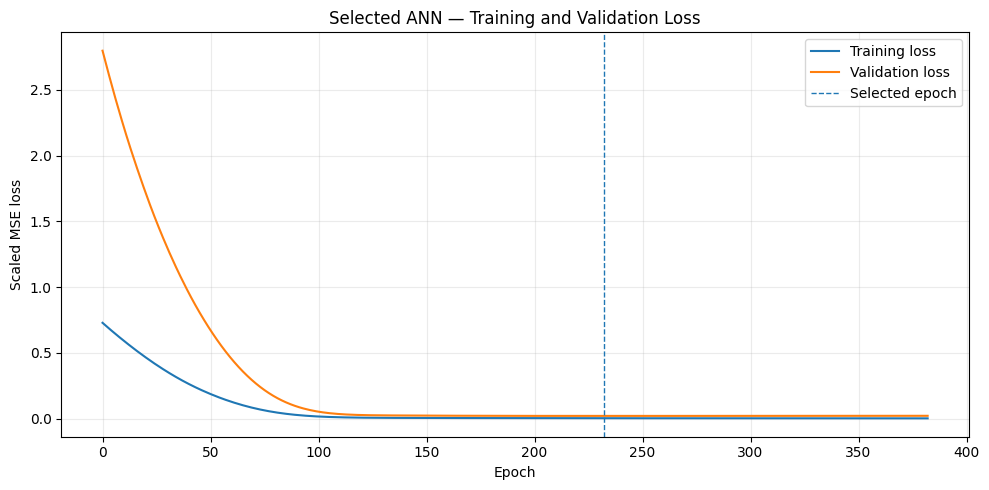

In [11]:
selected_history = PREFERRED_ANN_RESULT

plt.figure(figsize=(10, 5))
plt.plot(selected_history["train_losses"], label="Training loss")
plt.plot(selected_history["valid_losses"], label="Validation loss")
plt.axvline(
    SELECTED_EPOCHS - 1,
    linestyle="--",
    linewidth=1,
    label="Selected epoch",
)
plt.title("Selected ANN — Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Scaled MSE loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 12. Validation comparison with the classical model and baseline

Notebook 03 selected **autoregressive Lasso Regression with α = 10** using the same validation period. It is recreated here so that the deep-learning result is compared under identical data splits.

The persistence baseline predicts next month's price as the latest observed house price.

In [12]:
lasso = Pipeline([
    ("scale", StandardScaler()),
    ("model", Lasso(alpha=10, max_iter=50_000)),
])

lasso.fit(
    train[AUTOREGRESSIVE_FEATURES],
    train[TARGET],
)

lasso_validation_pred = lasso.predict(
    validation[AUTOREGRESSIVE_FEATURES]
)

persistence_validation_pred = (
    validation["house_price_lag_1m_gbp"].to_numpy()
)

validation_benchmark = pd.DataFrame([
    {
        "model": PREFERRED_ANN_NAME,
        **PREFERRED_ANN_RESULT["metrics"],
    },
    {
        "model": "AR Lasso Regression",
        **regression_metrics(
            validation[TARGET],
            lasso_validation_pred,
        ),
    },
    {
        "model": "Persistence baseline",
        **regression_metrics(
            validation[TARGET],
            persistence_validation_pred,
        ),
    },
])

validation_benchmark.sort_values("RMSE")

,model,MAE,RMSE,MAPE_pct,R2
1,AR Lasso Regression,"1,451.903","1,890.397",0.603,0.939
2,Persistence baseline,"1,630.857","1,954.083",0.680,0.935
0,AR ANN — 16,"2,804.884","3,368.266",1.167,0.807


The ANN is retained even if it does not win the validation comparison. This is useful evidence because the model family is being evaluated on its merits rather than selected because it is more complex.

## 13. Refit the selected ANN on all development data

After architecture selection, training and validation observations are combined.

The feature and target scalers are refitted on the combined development period, and the selected ANN architecture is trained for the number of epochs chosen during validation.

The final test observations are still not used during fitting.

In [13]:
development = pd.concat([train, validation], ignore_index=True)

def fit_final_ann(config, epochs, seed=SEED):
    set_seed(seed)

    features = config["features"]

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_dev = x_scaler.fit_transform(development[features])
    y_dev = y_scaler.fit_transform(development[[TARGET]]).ravel()

    X_test = x_scaler.transform(test[features])

    X_dev_t = torch.tensor(X_dev, dtype=torch.float32)
    y_dev_t = torch.tensor(y_dev, dtype=torch.float32)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    model = PriceANN(
        n_features=len(features),
        hidden_layers=config["hidden_layers"],
        dropout=config["dropout"],
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    loss_fn = nn.MSELoss()
    development_losses = []

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()

        prediction = model(X_dev_t)
        loss = loss_fn(prediction, y_dev_t)

        loss.backward()
        optimizer.step()

        development_losses.append(float(loss.item()))

    model.eval()

    with torch.no_grad():
        scaled_prediction = model(X_test_t).numpy().reshape(-1, 1)

    test_prediction = (
        y_scaler.inverse_transform(scaled_prediction).ravel()
    )

    return {
        "model": model,
        "x_scaler": x_scaler,
        "y_scaler": y_scaler,
        "prediction": test_prediction,
        "losses": development_losses,
    }

final_ann = fit_final_ann(
    PREFERRED_ANN_CONFIG,
    epochs=SELECTED_EPOCHS,
)

## 14. Final untouched test evaluation

In [14]:
ann_test_pred = final_ann["prediction"]

# Refit the selected classical comparator on the full development period.
final_lasso = Pipeline([
    ("scale", StandardScaler()),
    ("model", Lasso(alpha=10, max_iter=50_000)),
])

final_lasso.fit(
    development[AUTOREGRESSIVE_FEATURES],
    development[TARGET],
)

lasso_test_pred = final_lasso.predict(
    test[AUTOREGRESSIVE_FEATURES]
)

persistence_test_pred = (
    test["house_price_lag_1m_gbp"].to_numpy()
)

annual_drift_test_pred = (
    test["house_price_lag_1m_gbp"].to_numpy()
    + (
        test["house_price_lag_1m_gbp"].to_numpy()
        - test["house_price_lag_12m_gbp"].to_numpy()
    ) / 11
)

test_comparison = pd.DataFrame([
    {
        "model": PREFERRED_ANN_NAME,
        **regression_metrics(test[TARGET], ann_test_pred),
    },
    {
        "model": "AR Lasso Regression",
        **regression_metrics(test[TARGET], lasso_test_pred),
    },
    {
        "model": "Persistence baseline",
        **regression_metrics(test[TARGET], persistence_test_pred),
    },
    {
        "model": "Annual-drift baseline",
        **regression_metrics(test[TARGET], annual_drift_test_pred),
    },
])

test_comparison.sort_values("RMSE")

,model,MAE,RMSE,MAPE_pct,R2
1,AR Lasso Regression,"3,255.293","4,955.843",1.213,0.844
3,Annual-drift baseline,"3,596.561","5,215.396",1.332,0.828
2,Persistence baseline,"3,727.899","5,247.147",1.381,0.826
0,AR ANN — 16,"5,452.752","6,444.880",1.978,0.737


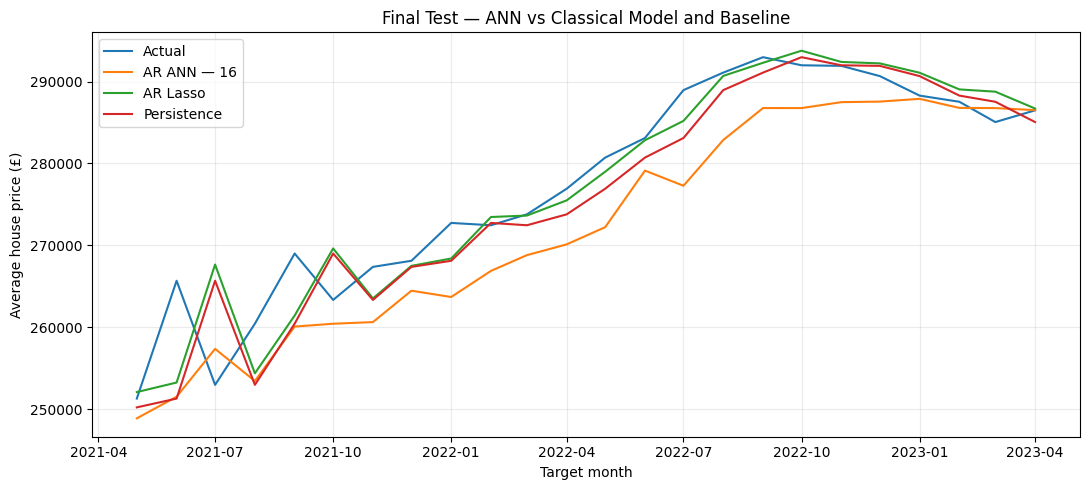

In [15]:
plt.figure(figsize=(11, 5))
plt.plot(test["target_date"], test[TARGET], label="Actual")
plt.plot(test["target_date"], ann_test_pred, label=PREFERRED_ANN_NAME)
plt.plot(test["target_date"], lasso_test_pred, label="AR Lasso")
plt.plot(test["target_date"], persistence_test_pred, label="Persistence")
plt.title("Final Test — ANN vs Classical Model and Baseline")
plt.xlabel("Target month")
plt.ylabel("Average house price (£)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 15. ANN residual analysis

In [16]:
ann_predictions = pd.DataFrame({
    "target_date": test["target_date"].to_numpy(),
    "actual_gbp": test[TARGET].to_numpy(),
    "predicted_gbp": ann_test_pred,
})

ann_predictions["residual_gbp"] = (
    ann_predictions["actual_gbp"]
    - ann_predictions["predicted_gbp"]
)

ann_predictions["absolute_error_gbp"] = (
    ann_predictions["residual_gbp"].abs()
)

ann_predictions["absolute_percentage_error"] = (
    ann_predictions["absolute_error_gbp"]
    / ann_predictions["actual_gbp"]
    * 100
)

ann_predictions.head()

,target_date,actual_gbp,predicted_gbp,residual_gbp,absolute_error_gbp,absolute_percentage_error
0,2021-05-01,"251,285.480","248,870.953","2,414.527","2,414.527",0.961
1,2021-06-01,"265,676.075","251,513.156","14,162.919","14,162.919",5.331
2,2021-07-01,"252,960.133","257,357.219","-4,397.086","4,397.086",1.738
3,2021-08-01,"260,429.179","253,429.875","6,999.304","6,999.304",2.688
4,2021-09-01,"269,003.075","260,076.594","8,926.481","8,926.481",3.318


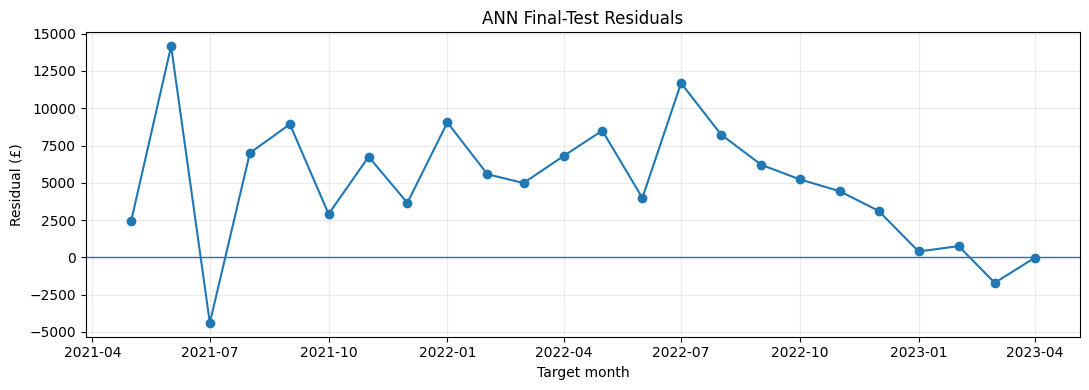

In [17]:
plt.figure(figsize=(11, 4))
plt.plot(
    ann_predictions["target_date"],
    ann_predictions["residual_gbp"],
    marker="o",
)
plt.axhline(0, linewidth=1)
plt.title("ANN Final-Test Residuals")
plt.xlabel("Target month")
plt.ylabel("Residual (£)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [18]:
ann_predictions.sort_values(
    "absolute_error_gbp",
    ascending=False,
).head(10)

,target_date,actual_gbp,predicted_gbp,residual_gbp,absolute_error_gbp,absolute_percentage_error
1,2021-06-01,"265,676.075","251,513.156","14,162.919","14,162.919",5.331
14,2022-07-01,"288,960.850","277,278.719","11,682.131","11,682.131",4.043
8,2022-01-01,"272,738.317","263,691.625","9,046.692","9,046.692",3.317
4,2021-09-01,"269,003.075","260,076.594","8,926.481","8,926.481",3.318
12,2022-05-01,"280,718.980","272,220.750","8,498.230","8,498.230",3.027
15,2022-08-01,"291,098.514","282,864.562","8,233.952","8,233.952",2.829
3,2021-08-01,"260,429.179","253,429.875","6,999.304","6,999.304",2.688
11,2022-04-01,"276,916.618","270,121.500","6,795.118","6,795.118",2.454
6,2021-11-01,"267,369.958","260,625.156","6,744.802","6,744.802",2.523
16,2022-09-01,"292,981.950","286,769.500","6,212.450","6,212.450",2.120


## 16. What the ANN experiment shows

The selected neural network uses a compact architecture rather than a large deep network. This is appropriate because the available monthly sample is small.

Several conclusions follow from the experiment:

1. **Scaling materially matters for ANN training.** Features and the regression target are standardised using training-only statistics.
2. **Early stopping is essential.** Validation loss is monitored to avoid continuing optimisation after generalisation stops improving.
3. **A smaller network can outperform a deeper network on limited tabular data.** Additional layers do not automatically provide better forecasts.
4. **The full macroeconomic ANN does not outperform the autoregressive ANN at the one-month horizon.** This is consistent with the ablation findings from Notebook 03.
5. **The ANN does not outperform the selected regularised Lasso model on the untouched final test.** The simpler classical model remains the preferred forecasting model.
6. **The negative comparison is retained transparently.** Deep learning is evaluated as one modelling approach rather than assumed to be superior.

This is an important modelling result: model complexity should be justified by out-of-time predictive performance, not by the sophistication of the algorithm.

## 17. Deep-learning methodology summary

The portfolio reconstruction strengthens the neural-network component by demonstrating a complete deep-learning workflow:

- PyTorch implementation;
- explicit network architecture;
- ReLU nonlinear activation;
- Adam optimisation;
- mean-squared-error loss;
- training-only feature and target scaling;
- deterministic random seeds;
- validation-based architecture selection;
- early stopping;
- chronological final-test evaluation;
- residual analysis;
- fair comparison with a regularised linear model and forecasting baselines.

The next notebook will consolidate the classical and ANN results, add model interpretability and sensitivity analysis, and document the final model-selection decision.